In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../../utils/') 
from post_anal_plot import * 

### static LCI +  three GWP
- GWP100
- pGWP-fixed vs. dp-CO2 

In [3]:
wind  = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/hydro_reservoir_CN-asRoW_US-asQC_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

In [4]:
def tidy(df, tech_label):
    parts = df["Activity"].str.split(", ", expand=True)
    out = df.copy()
    out["Technology"] = tech_label
    out["Country"]    = parts[3].str[:2]
    out["SSP"]        = parts[4]
    out["Year"]       = parts[5].astype(int)
    return out[["Technology", "Country", "SSP", "Year",
                "gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]]

all_df = pd.concat(
    [tidy(wind,  "Wind"),
     tidy(hydro, "Hydro"),
     tidy(pv,    "PV")],
    ignore_index=True,
)

# Keep only 2030 & 2050
df = all_df[all_df["Year"].isin([2030, 2050])].copy()

# long format over metrics
metric_cols = ["gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]
df_long = df.melt(
    id_vars=["Technology", "Country", "SSP", "Year"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

df_long


,Technology,Country,SSP,Year,Metric,Score
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036906
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017833
2,Wind,CN,SSP2-M,2030,gwp100,0.037725
3,Wind,CN,SSP2-M,2050,gwp100,0.031186
4,Wind,CN,SSP5-H,2030,gwp100,0.038735
...,...,...,...,...,...,...
103,PV,US,SSP1-VLLO,2050,pGWP100_dpCO2,0.006247
104,PV,US,SSP2-M,2030,pGWP100_dpCO2,0.020169
105,PV,US,SSP2-M,2050,pGWP100_dpCO2,0.012675
106,PV,US,SSP5-H,2030,pGWP100_dpCO2,0.020844


In [5]:
df_long.sort_values([ "SSP","Year", "Country", "Technology"	]).to_excel("plot_rankshift_staticLCI.xlsx",  index = False)

### adding:  dpLCI + pGWP-fixedCO2

In [6]:
import pickle
import pandas as pd

with open("../dp-LCI_output/hydro_dpLCI_reservoir/hydro_reservoir_dp_results_MY2030_2050.pkl","rb") as f:
    hydro_dp = pickle.load(f)

with open("../dp-LCI_output/pv_dpLCI/PV_dp_results_MY2030_2050.pkl","rb") as f:
    pv_dp = pickle.load(f)

with open("../dp-LCI_output/wind_dpLCI/wind_dp_results_MY2030_2050.pkl","rb") as f:
    wind_dp = pickle.load(f)


def extract_from_dp_dict(dp_dict):
    rows = []

    # map raw activity-tech strings to tidy Technology label
    tech_map = {
        "wind": "Wind",
        "pv": "PV",
        "photovoltaic": "PV",
        "hydro": "Hydro",
    }

    def normalize_raw_tech(raw_tech):
        """Normalize raw technology string before mapping."""
        raw = str(raw_tech).strip().lower()
        if raw in ["pv", "photovoltaic"]:
            return "pv"
        if raw == "wind":
            return "wind"
        if raw == "hydro":
            return "hydro"
        return raw

    def collapse_country(region, tech):
        """
        Collapse detailed region labels to plot-country labels.

        Rules:
        - Hydro special remap:
            CA-QC -> US
            RoW   -> CN
        - Otherwise:
            US-* / US -> US
            CN-* / CN -> CN
        - Else return original region
        """
        region = str(region).strip()

        # ---- Hydro special remap ----
        if tech == "Hydro":
            if region == "CA-QC":
                return "US"
            if region == "RoW":
                return "CN"

        # ---- Generic collapse for other technologies ----
        if region == "US" or region.startswith("US"):
            return "US"
        if region == "CN" or region.startswith("CN"):
            return "CN"

        return region

    for act, metrics in dp_dict.items():
        parts = act.split(", ")

        # expected structure:
        # parts[1] = tech
        # parts[3] = region
        # parts[4] = SSP
        # parts[5] = year
        if len(parts) < 6:
            print(f"Skipping malformed key: {act}")
            continue

        raw_tech = normalize_raw_tech(parts[1])

        if raw_tech not in tech_map:
            print(f"Unexpected tech label: {parts[1]}")
            continue

        tech = tech_map[raw_tech]
        region = parts[3]
        country = collapse_country(region, tech)
        ssp = parts[4]

        try:
            year = int(parts[5])
        except ValueError:
            print(f"Unexpected year in key: {act}")
            continue

        # keep only 2030 & 2050
        if year not in (2030, 2050):
            continue

        for metric_name, value in metrics.items():
            rows.append(
                {
                    "Technology": tech,
                    "Country": country,
                    "SSP": ssp,
                    "Year": year,
                    "Metric": metric_name,
                    "Score": float(value),
                }
            )

    return pd.DataFrame(rows)


df_hydro_dp = extract_from_dp_dict(hydro_dp)
df_pv_dp    = extract_from_dp_dict(pv_dp)
df_wind_dp  = extract_from_dp_dict(wind_dp)

df_dp = pd.concat([df_hydro_dp, df_pv_dp, df_wind_dp], ignore_index=True)

print(len(df_dp))
df_dp

72


,Technology,Country,SSP,Year,Metric,Score
0,Hydro,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.051877
1,Hydro,CN,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.052092
2,Hydro,US,SSP2-M,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.031584
3,Hydro,US,SSP2-M,2030,"full dp-LCI, pGWP100-fixedCO2",0.029088
4,Hydro,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.028855
...,...,...,...,...,...,...
67,Wind,US,SSP2-M,2030,"full dp-LCI, pGWP100-fixedCO2",0.024641
68,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.018225
69,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.022422
70,Wind,CN,SSP2-M,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.043338


In [7]:
#df_dp 
df_full = pd.concat([df_long, df_dp], ignore_index=True)
df_full

,Technology,Country,SSP,Year,Metric,Score
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036906
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017833
2,Wind,CN,SSP2-M,2030,gwp100,0.037725
3,Wind,CN,SSP2-M,2050,gwp100,0.031186
4,Wind,CN,SSP5-H,2030,gwp100,0.038735
...,...,...,...,...,...,...
175,Wind,US,SSP2-M,2030,"full dp-LCI, pGWP100-fixedCO2",0.024641
176,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.018225
177,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.022422
178,Wind,CN,SSP2-M,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.043338


## now ranking 

In [8]:
# NOW recompute Rank with the two new metrics included
df_full["Rank"] = df_full.groupby(
    ["Country","SSP","Year","Metric"]
)["Score"].rank(method="dense", ascending=True)

df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036906,2.0
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017833,2.0
2,Wind,CN,SSP2-M,2030,gwp100,0.037725,2.0
3,Wind,CN,SSP2-M,2050,gwp100,0.031186,2.0
4,Wind,CN,SSP5-H,2030,gwp100,0.038735,2.0
...,...,...,...,...,...,...,...
175,Wind,US,SSP2-M,2030,"full dp-LCI, pGWP100-fixedCO2",0.024641,2.0
176,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.018225,2.0
177,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.022422,2.0
178,Wind,CN,SSP2-M,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.043338,2.0


In [9]:
metric_rename = {
    "gwp100": "staticLCI + IPCC-GWP",
    "pGWP100_fixedCO2": "staticLCI + pGWP-fixedCO2",
    "pGWP100_dpCO2": "staticLCI + pGWP-dpCO2",
    "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": "dyn-FG-LCI + pGWP-fixedCO2",
    "full dp-LCI, pGWP100-fixedCO2": "full dpLCI + pGWP-fixedCO2"
}

In [10]:
df_full["Metric"] = df_full["Metric"].replace(metric_rename)

In [11]:
df_full_sorted = df_full.sort_values([ "SSP","Year", "Country", "Technology"	]) 
df_full_sorted

,Technology,Country,SSP,Year,Metric,Score,Rank
18,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.050523,3.0
54,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.051877,3.0
90,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.050841,3.0
108,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.051877,3.0
109,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.052092,3.0
...,...,...,...,...,...,...,...
11,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.019235,2.0
47,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.023259,2.0
83,Wind,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.018839,2.0
166,Wind,US,SSP5-H,2050,dyn-FG-LCI + pGWP-fixedCO2,0.023259,2.0


In [13]:
df_full_sorted.to_excel("plot_rankshift_whdpLCI.xlsx", index = False)

## plot 

In [2]:
df_full = pd.read_excel("plot_rankshift_whdpLCI.xlsx")
#df_full_sorted.head()

# remove the index column if present
if "Unnamed: 0" in df_full.columns:
    df_full = df_full.drop(columns=["Unnamed: 0"])


#### plot 

### because it's uniform distribution on the FG dyn LCI, 
##### so without full dpLCI (mapping to the right background), it the same score on dyn-FG-LCI vs. static LCI 
##### also, not showing the staticLCI + pGWP-dpCO2' caz in the excel (B.0) it's not changing that much to IPCC-GWP anyways

In [14]:
df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Wind,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.036906,2.0
1,Wind,CN,SSP1-VLLO,2050,staticLCI + IPCC-GWP,0.017833,2.0
2,Wind,CN,SSP2-M,2030,staticLCI + IPCC-GWP,0.037725,2.0
3,Wind,CN,SSP2-M,2050,staticLCI + IPCC-GWP,0.031186,2.0
4,Wind,CN,SSP5-H,2030,staticLCI + IPCC-GWP,0.038735,2.0
...,...,...,...,...,...,...,...
175,Wind,US,SSP2-M,2030,full dpLCI + pGWP-fixedCO2,0.024641,2.0
176,Wind,US,SSP2-M,2050,dyn-FG-LCI + pGWP-fixedCO2,0.018225,2.0
177,Wind,US,SSP2-M,2050,full dpLCI + pGWP-fixedCO2,0.022422,2.0
178,Wind,CN,SSP2-M,2030,dyn-FG-LCI + pGWP-fixedCO2,0.043338,2.0


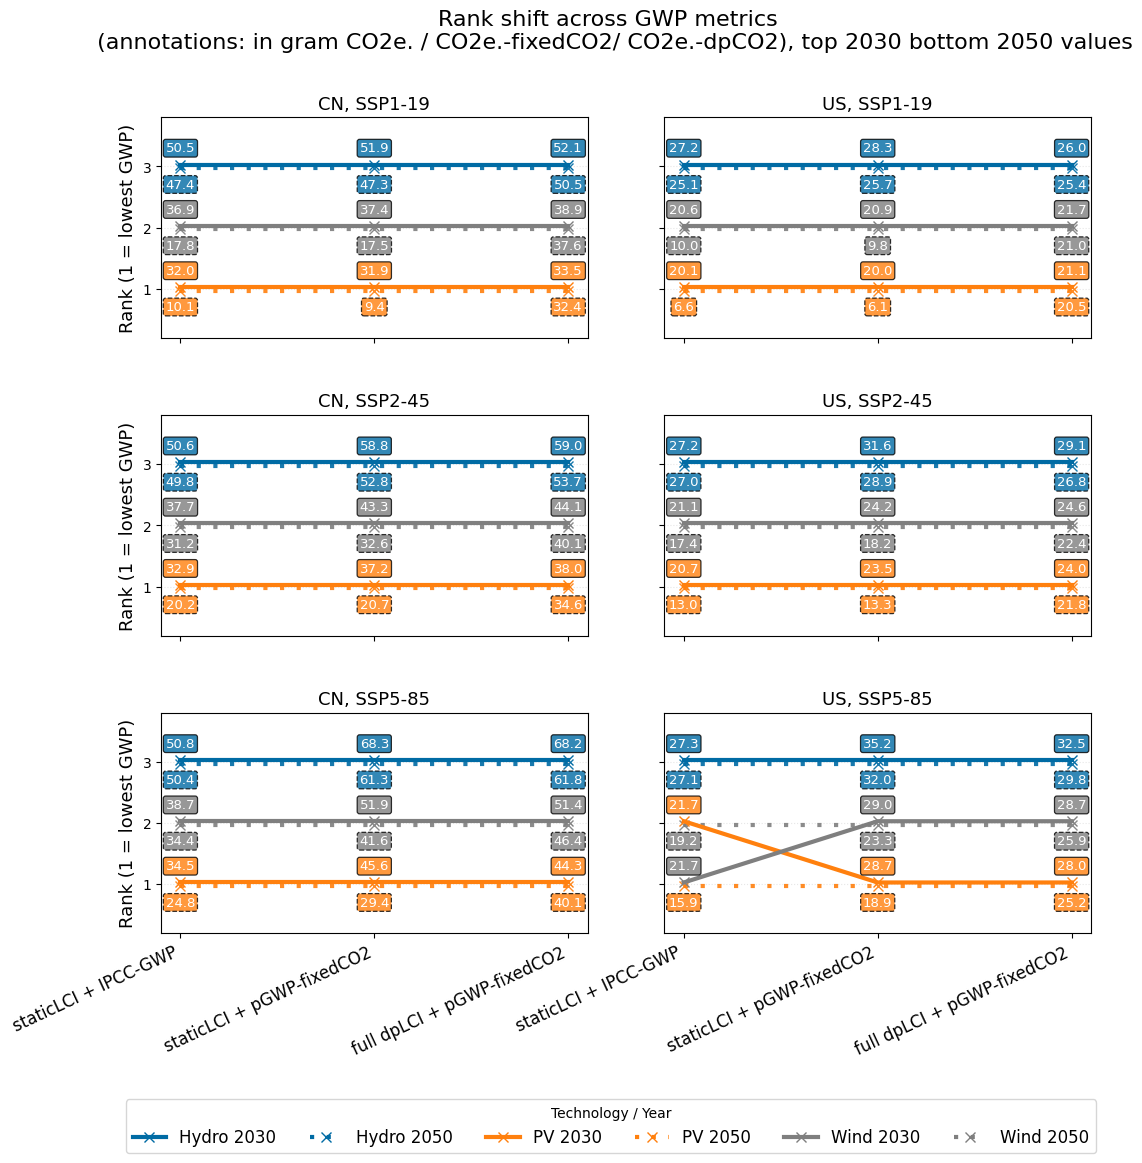

In [15]:
metric_order = [  #'dyn-FG-LCI + pGWP-fixedCO2', 
        
                  'staticLCI + IPCC-GWP', 
                  'staticLCI + pGWP-fixedCO2', 
                  #'staticLCI + pGWP-dpCO2', 
                 'full dpLCI + pGWP-fixedCO2',
                ]

metric_labels = {
    'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP', 
    'staticLCI + pGWP-fixedCO2':'staticLCI + pGWP-fixedCO2', 
    'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',   
    #'dyn-FG-LCI + pGWP-fixedCO2':'dyn-FG-LCI + pGWP-fixedCO2' ,
    'full dpLCI + pGWP-fixedCO2': 'full dpLCI + pGWP-fixedCO2',
}

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}

fig, axes = rank_shift_plot_cleanSeparated(
    df_full,
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
    fig_title=  "Rank shift across GWP metrics \n (annotations: in gram CO2e. / CO2e.-fixedCO2/ CO2e.-dpCO2), top 2030 bottom 2050 values",
)